In [19]:
import pandas as pd

In [20]:
df = pd.read_csv("data/customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [22]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [23]:
df['booking_complete'].value_counts(normalize=True)

booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64

In [24]:
cat_cols = ['sales_channel','trip_type','flight_day','route','booking_origin']
for c in cat_cols:
    print(c, '-> unique values:', df[c].nunique())

sales_channel -> unique values: 2
trip_type -> unique values: 3
flight_day -> unique values: 7
route -> unique values: 799
booking_origin -> unique values: 104


In [25]:
df.groupby('sales_channel')['booking_complete'].mean()

sales_channel
Internet    0.154770
Mobile      0.108402
Name: booking_complete, dtype: float64

In [26]:
df.groupby('trip_type')['booking_complete'].mean()

trip_type
CircleTrip    0.043103
OneWay        0.051680
RoundTrip     0.150575
Name: booking_complete, dtype: float64

In [31]:
# create the grouped columns
top_routes = df['route'].value_counts().nlargest(20).index
df['route_grouped'] = df['route'].where(df['route'].isin(top_routes), 'Other')

top_origins = df['booking_origin'].value_counts().nlargest(20).index
df['booking_origin_grouped'] = df['booking_origin'].where(df['booking_origin'].isin(top_origins), 'Other')

# drop the ORIGINAL high-cardinality text columns so they don't sneak into X
df = df.drop(columns=['route', 'booking_origin'])

# now one-hot encode everything that's still text
cat_cols = ['sales_channel', 'trip_type', 'flight_day', 'route_grouped', 'booking_origin_grouped']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [32]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['booking_complete'])   # everything except the target = features
y = df_encoded['booking_complete']                   # just the target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [38]:
# Cross-validation on training data
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print('5-fold CV ROC-AUC scores:', cv_scores.round(3))
print('Mean CV ROC-AUC:', cv_scores.mean().round(3))

# Predict on held-out test set
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print('Test set ROC-AUC:', round(roc_auc_score(y_test, y_proba), 3))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

5-fold CV ROC-AUC scores: [0.765 0.768 0.769 0.752 0.758]
Mean CV ROC-AUC: 0.762
Test set ROC-AUC: 0.772
              precision    recall  f1-score   support

           0       0.94      0.67      0.78      8504
           1       0.29      0.76      0.42      1496

    accuracy                           0.68     10000
   macro avg       0.61      0.71      0.60     10000
weighted avg       0.84      0.68      0.73     10000

[[5667 2837]
 [ 360 1136]]


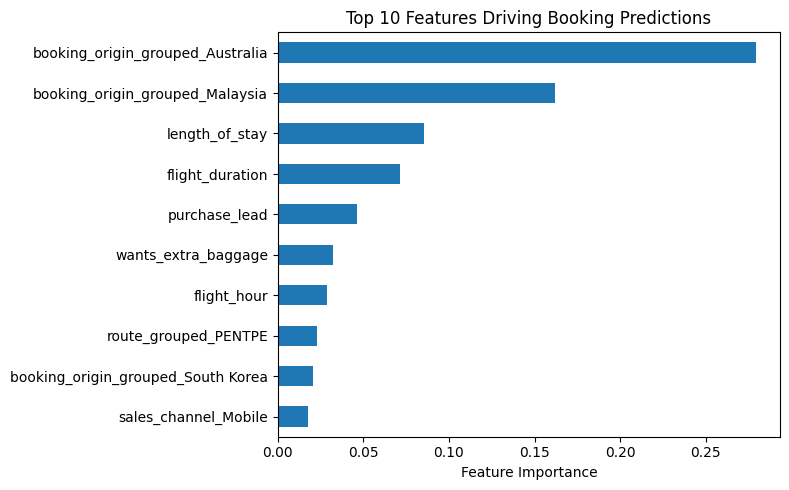

In [40]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh', color='#1f77b4')
plt.xlabel('Feature Importance')
plt.title('Top 10 Features Driving Booking Predictions')
plt.tight_layout()
plt.show()